<a href="https://colab.research.google.com/github/FrenklinV/cajupi-sales-analysis/blob/main/Cajupi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CAJUPI SALES



## Step 1 — Upload the files to Google Colab

In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving fatura_qershor_dataset_v2.xlsx to fatura_qershor_dataset_v2 (1).xlsx


In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving shitje_produkte_lidhur_me_fatura.xlsx to shitje_produkte_lidhur_me_fatura (3).xlsx


In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving fatura_korrik_dataset.csv to fatura_korrik_dataset.csv


In [ ]:
invoices = pd.read_excel("fatura_qershor_dataset_v2.xlsx")
items = pd.read_excel("shitje_produkte_lidhur_me_fatura.xlsx")

In [ ]:
print(invoices.head())
print(items.head())

   invoice_id       date   time  price_lek
0           1 2024-06-01  08:13       3350
1           2 2024-06-01  08:32        580
2           3 2024-06-01  08:43       3240
3           4 2024-06-01  08:50       2610
4           5 2024-06-01  08:51       2060
   item_id  invoice_id       date   time product_name  quantity
0        1           1 2024-06-01  08:13         Pace         2
1        2           2 2024-06-01  08:32        Pilaf         3
2        3           2 2024-06-01  08:32         Pace         3
3        4           3 2024-06-01  08:43          Uje         1
4        5           4 2024-06-01  08:50         Pace         1


## Step 2 — Basic cleaning and preparation

In [ ]:
import pandas as pd
import numpy as np

# convert date
invoices["date"] = pd.to_datetime(invoices["date"])
items["date"] = pd.to_datetime(items["date"])

# create hour column
invoices["hour"] = invoices["time"].str.slice(0, 2).astype(int)
items["hour"] = items["time"].str.slice(0, 2).astype(int)

# day name
invoices["day_name"] = invoices["date"].dt.day_name()
items["day_name"] = items["date"].dt.day_name()

# weekday/weekend flag
invoices["day_type"] = np.where(invoices["date"].dt.weekday < 5, "Weekday", "Weekend")
items["day_type"] = np.where(items["date"].dt.weekday < 5, "Weekday", "Weekend")

## Step 3 — Analyze the invoice table

In [ ]:
total_revenue = invoices["price_lek"].sum()
total_revenue


np.int64(2242020)

In [ ]:
total_invoices = invoices["invoice_id"].nunique()
total_invoices

1113

In [ ]:
avg_invoice = invoices["price_lek"].mean()
avg_invoice

np.float64(2014.3935309973047)

In [ ]:
invoices["price_lek"].min(), invoices["price_lek"].max()

(460, 3500)

In [ ]:
daily_revenue = invoices.groupby("date")["price_lek"].sum().reset_index()
daily_revenue.head()

,date,price_lek
0,2024-06-01,60960
1,2024-06-02,58400
2,2024-06-03,80200
3,2024-06-04,84550
4,2024-06-05,90810


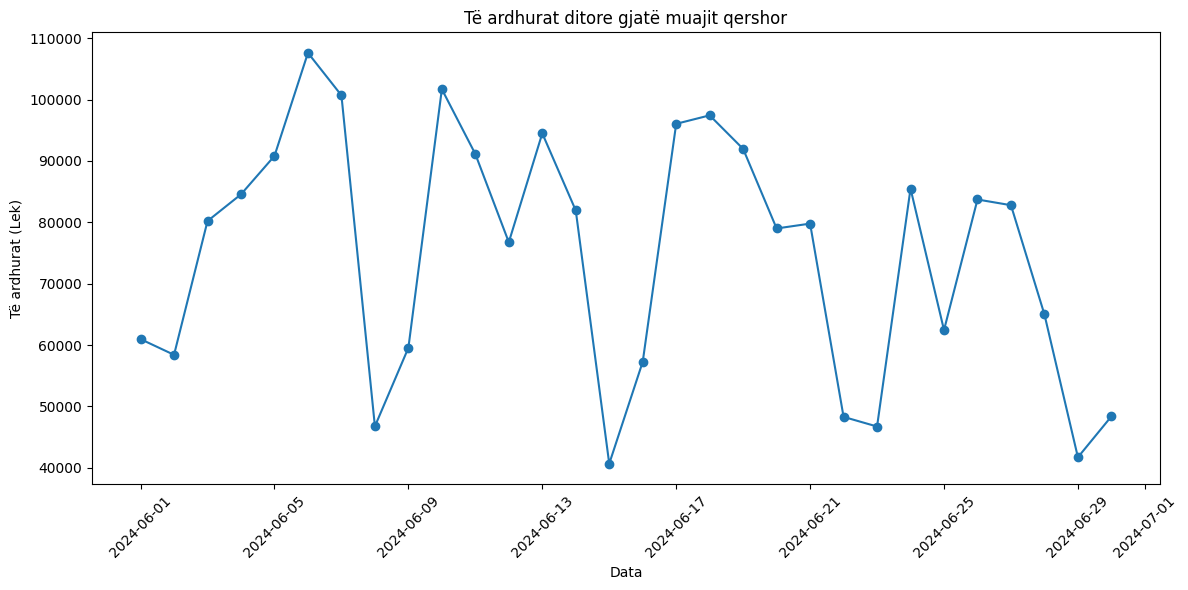

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(daily_revenue["date"], daily_revenue["price_lek"], marker="o")
plt.xticks(rotation=45)
plt.title("Të ardhurat ditore gjatë muajit qershor")
plt.xlabel("Data")
plt.ylabel("Të ardhurat (Lek)")
plt.tight_layout()
plt.show()

In [ ]:
hourly_revenue = invoices.groupby("hour")["price_lek"].sum().reset_index()
hourly_revenue

,hour,price_lek
0,8,486920
1,9,517520
2,10,100460
3,11,93430
4,12,266760
5,13,236070
6,14,274580
7,15,108620
8,16,77740
9,17,79920


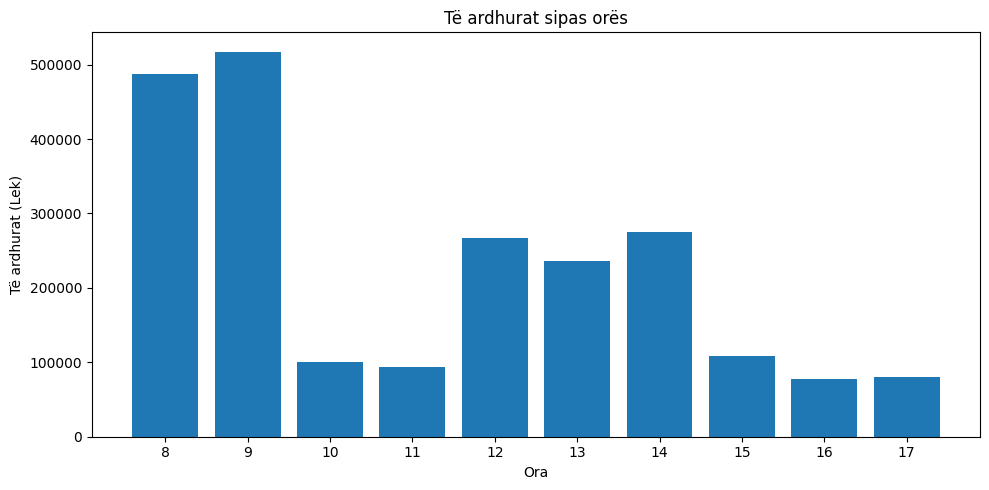

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(hourly_revenue["hour"], hourly_revenue["price_lek"])
plt.title("Të ardhurat sipas orës")
plt.xlabel("Ora")
plt.ylabel("Të ardhurat (Lek)")
plt.xticks(hourly_revenue["hour"])
plt.tight_layout()
plt.show()

## Step 4 — Number of invoices by hour

In [ ]:
hourly_invoices = invoices.groupby("hour")["invoice_id"].count().reset_index()
hourly_invoices

,hour,invoice_id
0,8,244
1,9,252
2,10,52
3,11,46
4,12,127
5,13,116
6,14,145
7,15,56
8,16,38
9,17,37


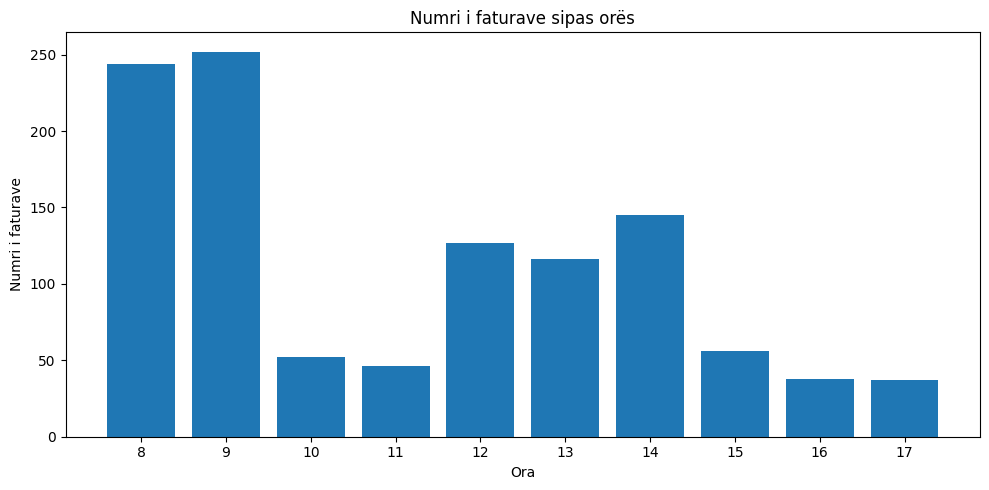

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(hourly_invoices["hour"], hourly_invoices["invoice_id"])
plt.title("Numri i faturave sipas orës")
plt.xlabel("Ora")
plt.ylabel("Numri i faturave")
plt.xticks(hourly_invoices["hour"])
plt.tight_layout()
plt.show()

## Step 5 — Weekday vs weekend

In [ ]:
daytype_revenue = invoices.groupby("day_type")["price_lek"].sum().reset_index()
daytype_revenue

,day_type,price_lek
0,Weekday,1733360
1,Weekend,508660


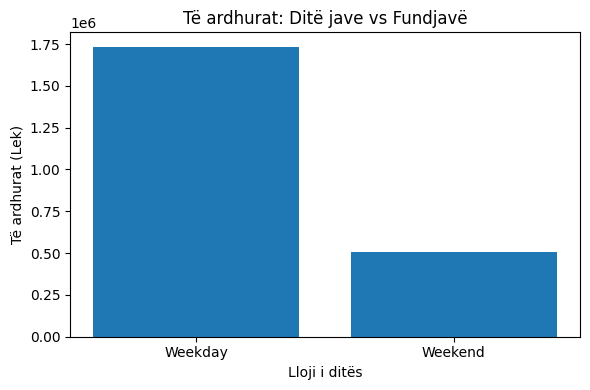

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(daytype_revenue["day_type"], daytype_revenue["price_lek"])
plt.title("Të ardhurat: Ditë jave vs Fundjavë")
plt.xlabel("Lloji i ditës")
plt.ylabel("Të ardhurat (Lek)")
plt.tight_layout()
plt.show()

In [ ]:
daytype_count = invoices.groupby("day_type")["invoice_id"].count().reset_index()
daytype_count

,day_type,invoice_id
0,Weekday,862
1,Weekend,251


## Step 6 — Product analysis

In [ ]:
product_sales = items.groupby("product_name")["quantity"].sum().sort_values(ascending=False).reset_index()
product_sales.head(10)

,product_name,quantity
0,Pilaf,404
1,Kafe,402
2,Pace,400
3,Tasqebab,371
4,Uje,365
5,Kos,333
6,Raki,331
7,Makarona,331
8,Pule ne zgare,331
9,Patate te skuqura,315


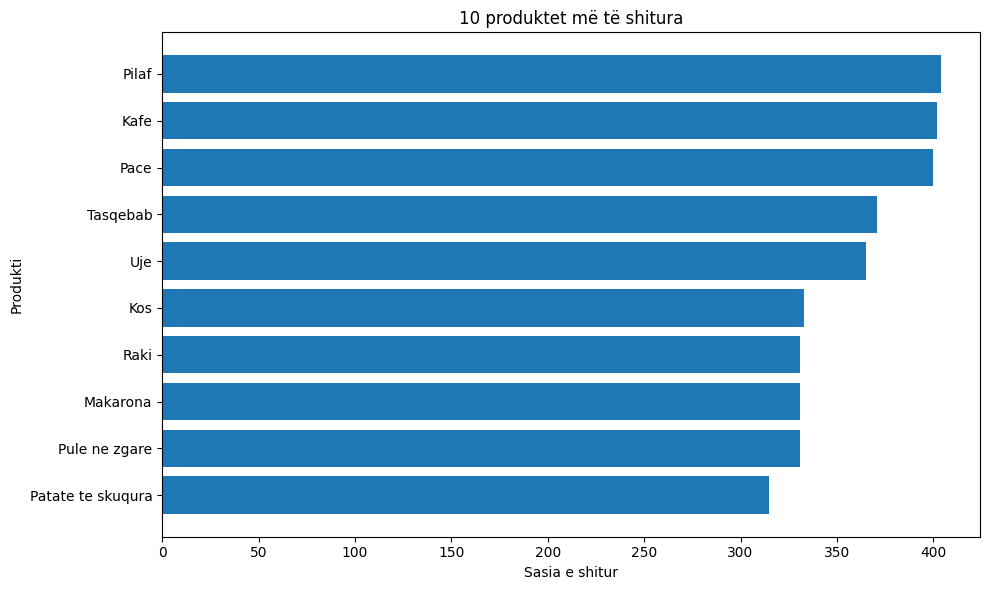

In [ ]:
top10 = product_sales.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["product_name"], top10["quantity"])
plt.gca().invert_yaxis()
plt.title("10 produktet më të shitura")
plt.xlabel("Sasia e shitur")
plt.ylabel("Produkti")
plt.tight_layout()
plt.show()

## Step 7 — Product sales by hour

In [ ]:
product_hour = items.groupby(["hour", "product_name"])["quantity"].sum().reset_index()
product_hour.head()

,hour,product_name,quantity
0,8,Byrek,46
1,8,Fergese,43
2,8,Kafe,137
3,8,Kos,114
4,8,Makarona,31


In [ ]:
main_products = ["Pace", "Pilaf", "Kos", "Kafe", "Tasqebab", "Uje", "Raki", "Supe"]
filtered = product_hour[product_hour["product_name"].isin(main_products)]

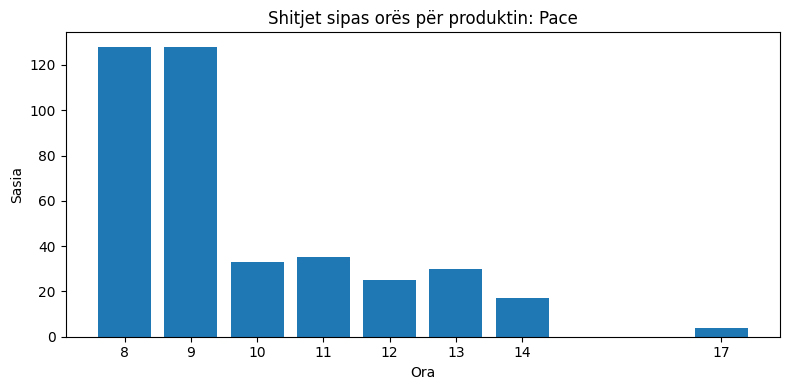

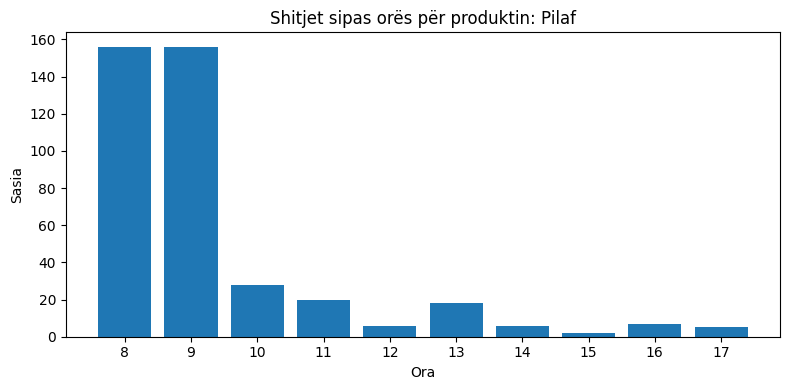

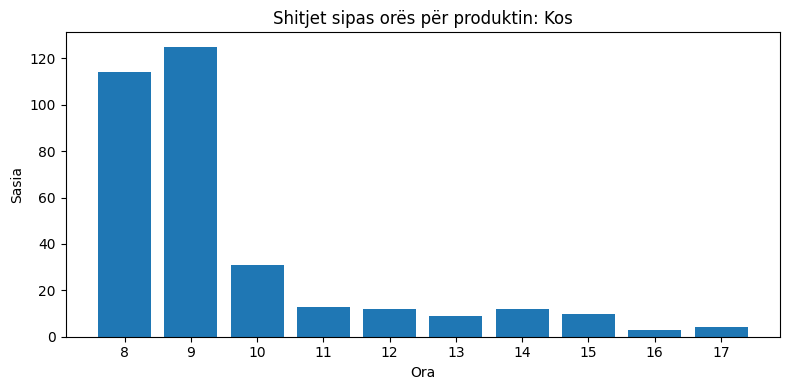

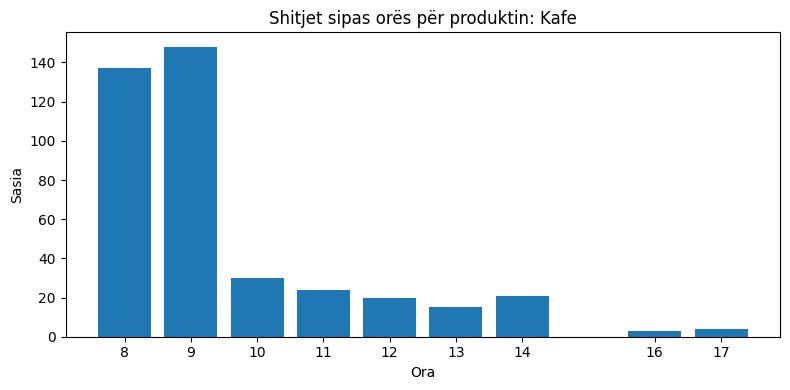

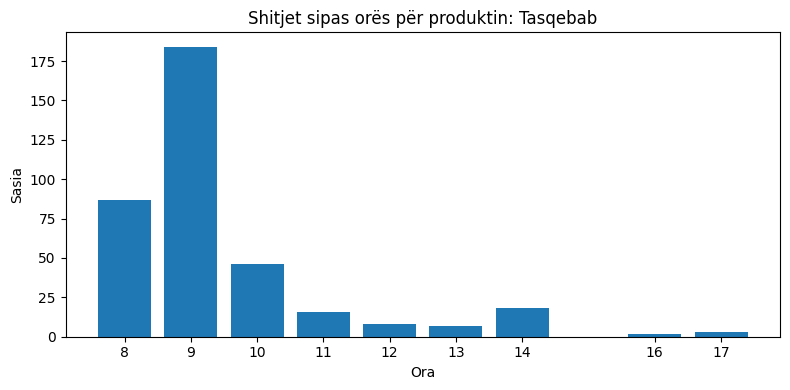

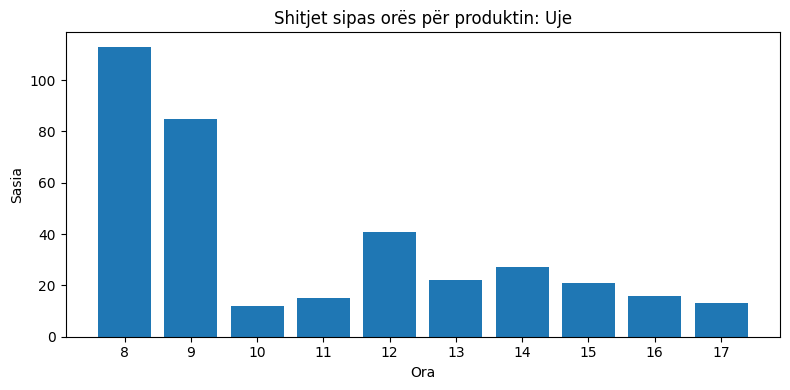

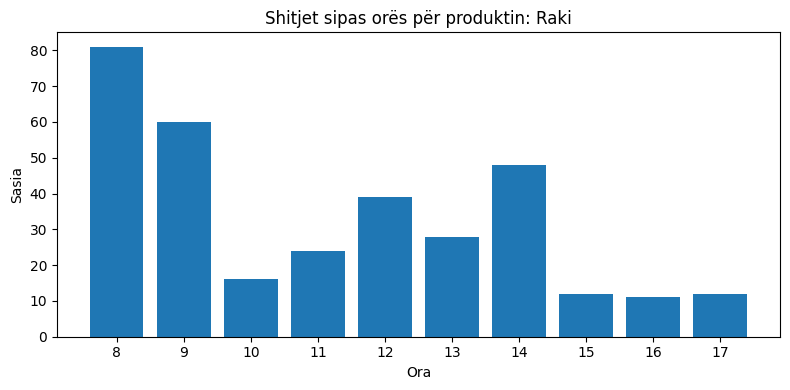

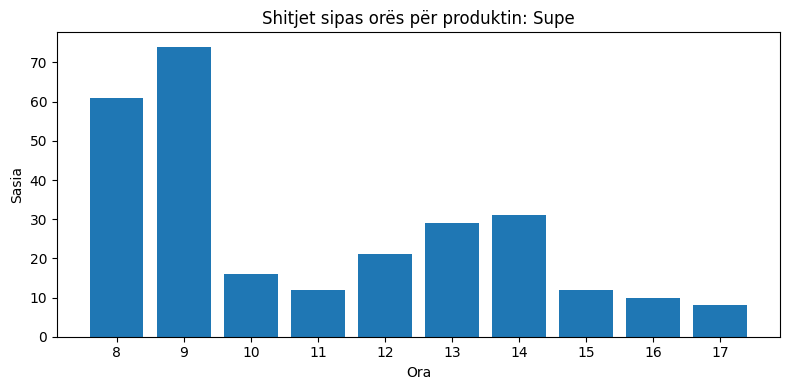

In [ ]:
for product in main_products:
    temp = filtered[filtered["product_name"] == product]
    plt.figure(figsize=(8,4))
    plt.bar(temp["hour"], temp["quantity"])
    plt.title(f"Shitjet sipas orës për produktin: {product}")
    plt.xlabel("Ora")
    plt.ylabel("Sasia")
    plt.xticks(sorted(temp["hour"].unique()))
    plt.tight_layout()
    plt.show()

## Step 8 — Morning vs afternoon product behavior

In [ ]:
items["time_period"] = np.where(items["hour"] < 12, "Morning", "Afternoon")

In [ ]:
period_product = items.groupby(["time_period", "product_name"])["quantity"].sum().reset_index()
period_product.head(20)

,time_period,product_name,quantity
0,Afternoon,Byrek,166
1,Afternoon,Fergese,176
2,Afternoon,Kafe,63
3,Afternoon,Kos,50
4,Afternoon,Makarona,239
5,Afternoon,Oriz me perime,187
6,Afternoon,Pace,76
7,Afternoon,Patate te skuqura,237
8,Afternoon,Pilaf,44
9,Afternoon,Pule ne zgare,215


## Step 9 — Merge both tables


In [ ]:
merged = items.merge(
    invoices[["invoice_id", "price_lek", "day_type", "hour"]],
    on="invoice_id",
    how="left"
)

merged.head()

,item_id,invoice_id,date,time,product_name,quantity,hour_x,day_name,day_type_x,time_period,price_lek,day_type_y,hour_y
0,1,1,2024-06-01,08:13,Pace,2,8,Saturday,Weekend,Morning,3350,Weekend,8
1,2,2,2024-06-01,08:32,Pilaf,3,8,Saturday,Weekend,Morning,580,Weekend,8
2,3,2,2024-06-01,08:32,Pace,3,8,Saturday,Weekend,Morning,580,Weekend,8
3,4,3,2024-06-01,08:43,Uje,1,8,Saturday,Weekend,Morning,3240,Weekend,8
4,5,4,2024-06-01,08:50,Pace,1,8,Saturday,Weekend,Morning,2610,Weekend,8


BOTH TOGETHER

12.1 Products in higher-value invoices

In [ ]:
product_avg_bill = (
    merged.groupby("product_name")
    .agg(
        total_qty=("quantity", "sum"),
        avg_invoice_value=("price_lek", "mean"),
        invoice_count=("invoice_id", "nunique")
    )
    .sort_values("avg_invoice_value", ascending=False)
    .reset_index()
)

product_avg_bill.head(10)

,product_name,total_qty,avg_invoice_value,invoice_count
0,Sallate Greke,288,2199.189189,140
1,Pule ne zgare,331,2123.048780,152
2,Oriz me perime,272,2119.772727,124
3,Speca me gjize,235,2089.090909,109
4,Tasqebab,371,2083.186813,161
5,Qofte,258,2079.851852,128
6,Uje,365,2056.685393,169
7,Pilaf,404,2053.000000,177
8,Patate te skuqura,315,2052.341772,147
9,Kafe,402,2038.484848,187


12.2 Product sales on weekdays vs weekends

In [ ]:
product_daytype = (
    merged.groupby(["product_name", "day_type_x"])["quantity"]
    .sum()
    .reset_index()
)

product_daytype_pivot = product_daytype.pivot(
    index="product_name",
    columns="day_type_x",
    values="quantity"
).fillna(0)

product_daytype_pivot["Total"] = product_daytype_pivot.sum(axis=1)
product_daytype_pivot = product_daytype_pivot.sort_values("Total", ascending=False)

product_daytype_pivot.head(10)

day_type_x,Weekday,Weekend,Total
product_name,,,
Pilaf,300,104,404
Kafe,320,82,402
Pace,303,97,400
Tasqebab,295,76,371
Uje,281,84,365
Kos,250,83,333
Raki,240,91,331
Makarona,272,59,331
Pule ne zgare,256,75,331


In [ ]:
display(product_daytype_pivot.head(10))

day_type_x,Weekday,Weekend,Total
product_name,,,
Pilaf,300,104,404
Kafe,320,82,402
Pace,303,97,400
Tasqebab,295,76,371
Uje,281,84,365
Kos,250,83,333
Raki,240,91,331
Makarona,272,59,331
Pule ne zgare,256,75,331


#KORRIKU

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

june = pd.read_excel("fatura_qershor_dataset_v2.xlsx")
july = pd.read_csv("fatura_korrik_dataset.csv")

In [ ]:
june["date"] = pd.to_datetime(june["date"])
july["date"] = pd.to_datetime(july["date"])

june["hour"] = june["time"].str[:2].astype(int)
july["hour"] = july["time"].str[:2].astype(int)

june["day_type"] = np.where(june["date"].dt.weekday < 5, "Weekday", "Weekend")
july["day_type"] = np.where(july["date"].dt.weekday < 5, "Weekday", "Weekend")

## Total revenue comparison

In [ ]:
comparison = pd.DataFrame({
    "Month": ["June", "July"],
    "Revenue": [june["price_lek"].sum(), july["price_lek"].sum()]
})

comparison

,Month,Revenue
0,June,2242020
1,July,2818640


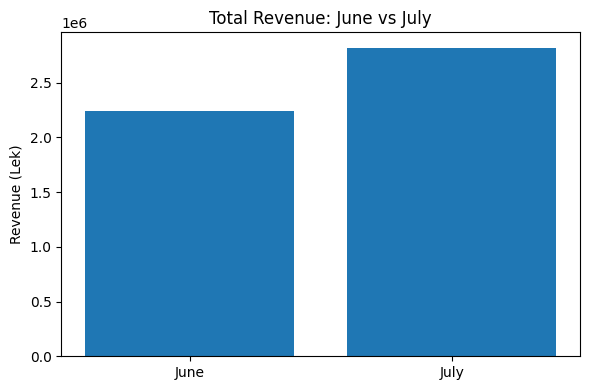

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(comparison["Month"], comparison["Revenue"])
plt.title("Total Revenue: June vs July")
plt.ylabel("Revenue (Lek)")
plt.tight_layout()
plt.show()

## Number of invoices comparison

In [ ]:
invoice_comp = pd.DataFrame({
    "Month": ["June", "July"],
    "Invoices": [june["invoice_id"].nunique(), july["invoice_id"].nunique()]
})

invoice_comp

,Month,Invoices
0,June,1113
1,July,1355


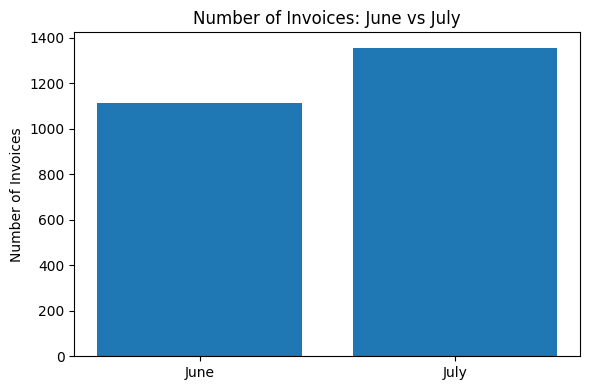

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(invoice_comp["Month"], invoice_comp["Invoices"])
plt.title("Number of Invoices: June vs July")
plt.ylabel("Number of Invoices")
plt.tight_layout()
plt.show()

## Average invoice value comparison

In [1]:
avg_comp = pd.DataFrame({
    "Month": ["June", "July"],
    "Average_Invoice": [june["price_lek"].mean(), july["price_lek"].mean()]
})

avg_comp

NameError: name 'pd' is not defined

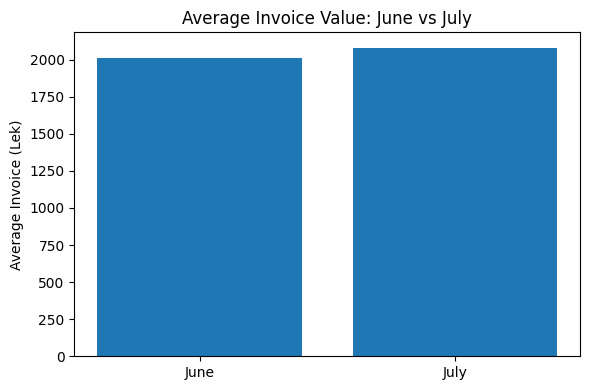

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(avg_comp["Month"], avg_comp["Average_Invoice"])
plt.title("Average Invoice Value: June vs July")
plt.ylabel("Average Invoice (Lek)")
plt.tight_layout()
plt.show()

Revenue by hour comparison

In [ ]:
june_hour = june.groupby("hour")["price_lek"].sum().reset_index()
july_hour = july.groupby("hour")["price_lek"].sum().reset_index()

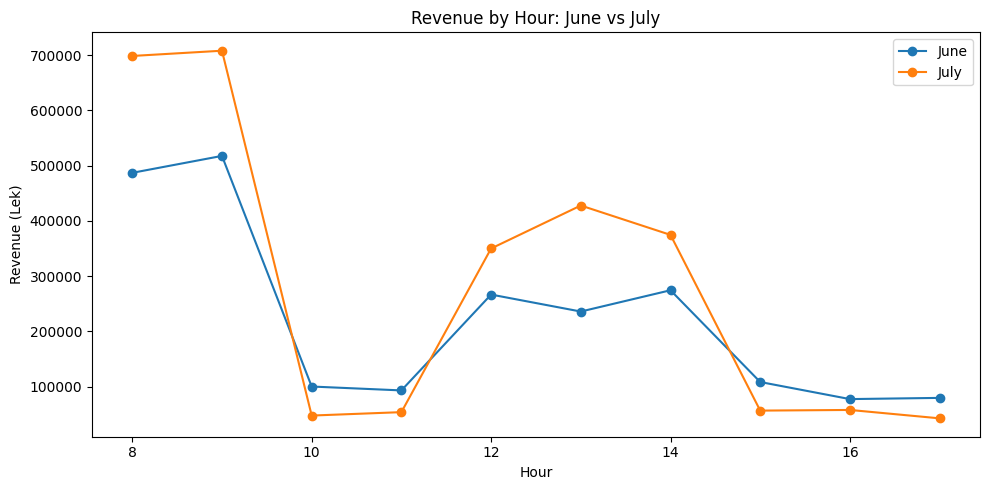

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(june_hour["hour"], june_hour["price_lek"], marker="o", label="June")
plt.plot(july_hour["hour"], july_hour["price_lek"], marker="o", label="July")
plt.title("Revenue by Hour: June vs July")
plt.xlabel("Hour")
plt.ylabel("Revenue (Lek)")
plt.legend()
plt.tight_layout()
plt.show()

Weekday vs weekend comparison

In [ ]:
june_daytype = june.groupby("day_type")["price_lek"].sum().reset_index()
july_daytype = july.groupby("day_type")["price_lek"].sum().reset_index()

June
  day_type  price_lek
0  Weekday    1733360
1  Weekend     508660
July
  day_type  price_lek
0  Weekday    2313310
1  Weekend     505330


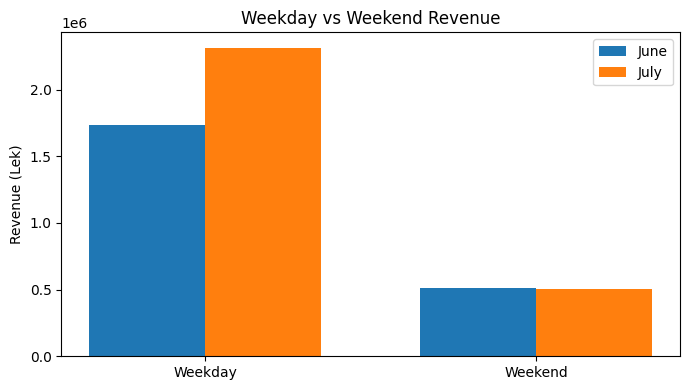

In [ ]:
fig, ax = plt.subplots(figsize=(7,4))

x = np.arange(2)
width = 0.35

ax.bar(x - width/2, june_daytype["price_lek"], width, label="June")
ax.bar(x + width/2, july_daytype["price_lek"], width, label="July")

ax.set_xticks(x)
ax.set_xticklabels(june_daytype["day_type"])
ax.set_title("Weekday vs Weekend Revenue")
ax.set_ylabel("Revenue (Lek)")
ax.legend()

plt.tight_layout()
plt.show()

## peak-hour revenue

In [ ]:
def is_peak(row):
    hour = int(row["time"][:2])
    minute = int(row["time"][3:5])
    return (
        (8 <= hour <= 9) or
        (hour == 12 and minute >= 30) or
        (hour == 13) or
        (hour == 14 and minute <= 30)
    )
june["peak"] = june.apply(is_peak, axis=1)
july["peak"] = july.apply(is_peak, axis=1)

peak_comp = pd.DataFrame({
    "Month": ["June", "July"],
    "Peak_Revenue": [
        june.loc[june["peak"], "price_lek"].sum(),
        july.loc[july["peak"], "price_lek"].sum()
    ]
})
peak_comp

,Month,Peak_Revenue
0,June,1781850
1,July,2558600


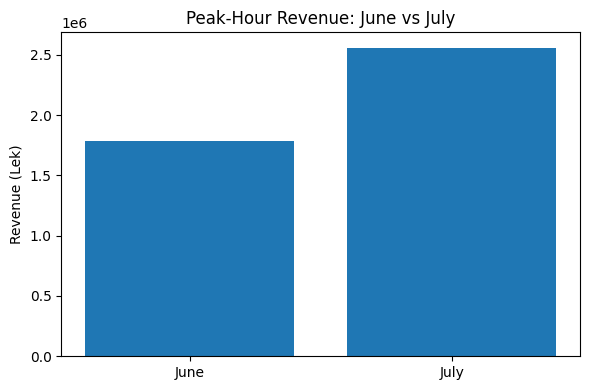

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(peak_comp["Month"], peak_comp["Peak_Revenue"])
plt.title("Peak-Hour Revenue: June vs July")
plt.ylabel("Revenue (Lek)")
plt.tight_layout()
plt.show()